# 04 — Advanced path: RFM+ features, whale split, richer representation

## How to read this notebook (learning design)

Notebooks **01–03 are unchanged** and remain the **baseline / learning track**.
This notebook starts the **advanced track**. We do **not** overwrite old results.

| Track | Notebooks | Purpose |
|-------|-----------|---------|
| Baseline | 01, 02, 03 | Classic RFM / spend, survey, production_score |
| Advanced | **04**, 05, 06 | Features+, whales, future eval, hybrid, soft/hier, scoring |

## Why we are doing this

With only Recency / Frequency / Monetary, many customers that *feel* different
(steady monthly buyer vs one big spike; high cancel rate; shrinking spend) look
almost the same in 3D space. That caps Silhouette and business lift.

**Improvements in this notebook**

1. **RFM+ features** — tenure, AOV, inter-purchase gaps, cancel rate, 90-day trends  
2. **Whale split** — top 1% Monetary managed separately so they do not own the centroids  
3. **Compare** baseline 3-feature clustering vs RFM+ on the **core** base (same algo)

Unsupervised only for labeling: still **no** segment ground truth / accuracy.

In [1]:
from __future__ import annotations

import random
import sys
import warnings
from pathlib import Path

import matplotlib

matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from segmentation.advanced.features_plus import (
    RFM_BASIC_COLS,
    RFM_PLUS_CLUSTER_COLS,
    build_rfm_plus,
    load_retail_transactions,
)
from segmentation.advanced.whales import split_whales
from segmentation.metrics import internal_metrics
from segmentation.preprocess import prepare_matrix

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
sns.set_theme(style="whitegrid")

print("Advanced track notebook 04 | root:", ROOT)

Advanced track notebook 04 | root: /home/ahmad/AI/Customer Segmentation


## 1. Load real transactions (Online Retail II)

Same UCI source as notebook 01 — we only **add** an advanced feature layer.

In [2]:
tx, meta = load_retail_transactions(ROOT, prefer="ii")
print(meta)
print("tx shape", tx.shape, "date", tx["invoice_date"].min(), "→", tx["invoice_date"].max())
display(tx.head(3))

{'dataset': 'ii', 'source': "UCI 502 xlsx sheets=['Year 2009-2010', 'Year 2010-2011']", 'colmap': {'invoice': 'Invoice', 'customer': 'Customer ID', 'qty': 'Quantity', 'price': 'Price', 'date': 'InvoiceDate', 'stock': 'StockCode', 'country': 'Country'}, 'n_raw': 1067371}
tx shape (1067371, 10) date 2009-12-01 07:45:00 → 2011-12-09 12:50:00


,invoice,stock_code,Description,quantity,invoice_date,unit_price,customer_id,country,is_cancel,line_total
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0


## 2. Build RFM+ (why each block exists)

| Feature group | Why |
|---------------|-----|
| R, F, M | Classic value/engagement |
| Tenure, inter-purchase mean/std | Distinguishes one-timers vs steady buyers |
| AOV + std | Basket quality / volatility |
| Cancel rate | Friction / return behavior |
| Unique stock & countries | Breadth of engagement |
| Last90 / Prev90 monetary + trend | **Trajectory**, not only lifetime total |

All features use history only (full sample as-of = max date here).

In [3]:
feat = build_rfm_plus(tx)
print("Customers with RFM+:", len(feat))
display(feat[RFM_PLUS_CLUSTER_COLS].describe().T.head(20))

Customers with RFM+: 5878


,count,mean,std,min,25%,50%,75%,max
Recency,5878.0,200.331916,209.338707,0.00,25.0000,95.000000,379.000000,738.00
Frequency,5878.0,6.289384,13.009406,1.00,1.0000,3.000000,7.000000,398.00
Monetary,5878.0,3018.616737,14737.731040,2.95,348.7625,898.915000,2307.090000,608821.65
TenureDays,5878.0,273.022457,258.807591,0.00,0.0000,220.500000,511.000000,738.00
AvgOrderValue,5878.0,391.726538,1215.071054,2.95,181.6525,285.070500,420.570000,84236.25
StdOrderValue,5878.0,158.547054,1196.413464,0.00,0.0000,73.252134,162.769997,84233.35
MeanInterPurchaseDays,5878.0,93.596734,84.659333,0.00,50.2500,72.000000,100.812500,714.00
StdInterPurchaseDays,5878.0,32.670786,45.604069,0.00,0.0000,13.000000,51.785322,350.50
CancelRate,5878.0,0.026916,0.068924,0.00,0.0000,0.000000,0.024793,0.75
NUniqueStock,5878.0,81.989112,116.484552,1.00,19.0000,45.000000,103.000000,2550.00


## 3. Whale split (production pattern)

**Why:** Top ~1% Monetary customers are operationally different (key accounts) and
statistically different (they drag KMeans centers). We **remove them from the
clustering matrix** and label them `Whale` by rule.

In [4]:
core, whales, thr = split_whales(feat, value_col="Monetary", upper_q=0.99)
print(f"Whale threshold Monetary ≥ {thr:,.2f}")
print(f"Core n={len(core):,} | Whales n={len(whales):,} ({100*len(whales)/len(feat):.2f}%)")
print(f"Whale share of lifetime Monetary: {100*whales['Monetary'].sum()/feat['Monetary'].sum():.1f}%")
display(whales[["customer_id", "Monetary", "Frequency", "Recency"]].sort_values("Monetary", ascending=False).head())

Whale threshold Monetary ≥ 29,730.42
Core n=5,819 | Whales n=59 (1.00%)
Whale share of lifetime Monetary: 31.9%


,customer_id,Monetary,Frequency,Recency
5692,18102.0,608821.65,145,0
2277,14646.0,528602.52,151,1
1789,14156.0,313946.37,156,9
2538,14911.0,295972.63,398,0
5050,17450.0,246973.09,51,7


## 4. Side-by-side: baseline RFM (3 cols) vs RFM+ on **core** only

Same algorithm (KMeans k=4, RobustScaler pipeline) so the lift is from **features**,
not from shopping a different estimator.

In [5]:
def fit_kmeans_block(df: pd.DataFrame, cols: list[str], k: int = 4, log_cols=None):
    log_cols = log_cols or [c for c in cols if c in {
        "Frequency", "Monetary", "AvgOrderValue", "StdOrderValue",
        "NUniqueStock", "MonetaryLast90", "MonetaryPrev90", "FreqLast90",
    }]
    X, work, sc, meta = prepare_matrix(df, cols, winsorize=True, log_cols=log_cols, scaler="robust")
    # choose k by silhouette among 2..6
    rows = []
    best = None
    for kk in range(2, 7):
        lab = KMeans(n_clusters=kk, random_state=SEED, n_init=30, max_iter=500).fit_predict(X)
        m = internal_metrics(X, lab)
        m["k"] = kk
        rows.append(m)
        if best is None or m["silhouette"] > best["silhouette"]:
            best = {**m, "k": kk, "labels": lab, "X": X}
    return pd.DataFrame(rows), best

basic_cols = [c for c in RFM_BASIC_COLS if c in core.columns]
plus_cols = [c for c in RFM_PLUS_CLUSTER_COLS if c in core.columns]

sweep_b, best_b = fit_kmeans_block(core, basic_cols)
sweep_p, best_p = fit_kmeans_block(core, plus_cols)

print("=== Baseline RFM (3 features) k-sweep on core ===")
display(sweep_b)
print("=== RFM+ k-sweep on core ===")
display(sweep_p)

print("\nPREFERRED baseline: k=%d Sil=%.4f CH=%.1f" % (best_b["k"], best_b["silhouette"], best_b["calinski_harabasz"]))
print("PREFERRED RFM+:     k=%d Sil=%.4f CH=%.1f" % (best_p["k"], best_p["silhouette"], best_p["calinski_harabasz"]))

=== Baseline RFM (3 features) k-sweep on core ===


,n_clusters,n_noise,noise_pct,largest_cluster_pct,min_cluster_pct,silhouette,davies_bouldin,calinski_harabasz,k
0,2,0,0.0,52.861316,47.138684,0.427847,0.872813,6287.759812,2
1,3,0,0.0,37.429112,30.641004,0.392757,0.912124,6164.171997,3
2,4,0,0.0,33.184396,19.848771,0.359538,0.913269,5951.465800,4
3,5,0,0.0,27.667984,15.346279,0.372911,0.861001,6074.430548,5
4,6,0,0.0,21.739130,10.414161,0.349487,0.888400,5907.354676,6


=== RFM+ k-sweep on core ===


,n_clusters,n_noise,noise_pct,largest_cluster_pct,min_cluster_pct,silhouette,davies_bouldin,calinski_harabasz,k
0,2,0,0.0,93.916480,6.083520,0.507158,0.943658,1712.927346,2
1,3,0,0.0,77.315690,5.155525,0.313905,1.138319,1899.047215,3
2,4,0,0.0,65.079911,4.794638,0.309129,1.159954,1925.446899,4
3,5,0,0.0,39.164805,4.485307,0.261064,1.274943,1945.041483,5
4,6,0,0.0,37.824368,1.993470,0.271333,1.189424,1926.137387,6



PREFERRED baseline: k=2 Sil=0.4278 CH=6287.8
PREFERRED RFM+:     k=2 Sil=0.5072 CH=1712.9


## 5. Profiles + PCA (RFM+ preferred)

,seg_plus,n,R,F,M,tenure,aov,trend90,cancel,pct
1,1,5465,197.483074,5.611345,2089.729097,272.891857,355.647882,183.557631,0.012944,93.91648
0,0,354,269.901130,4.299435,1852.977712,215.841808,441.365171,180.417429,0.234782,6.08352


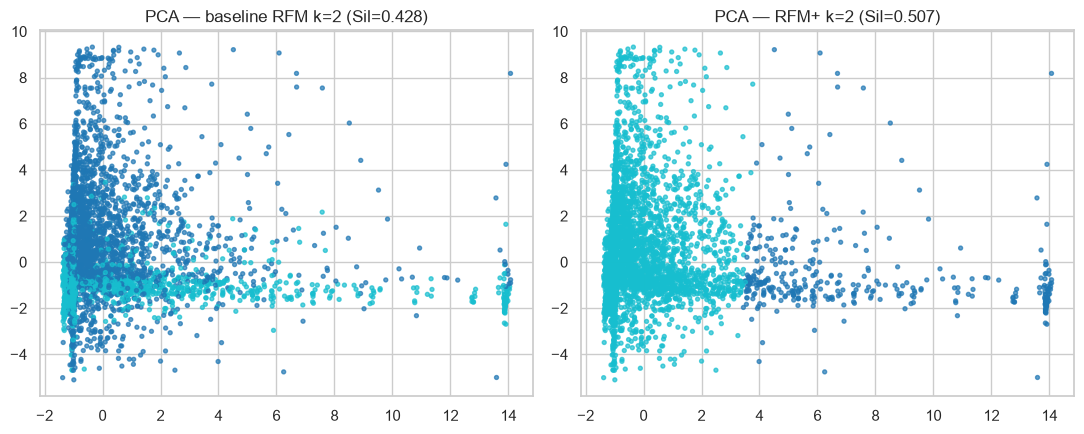

In [6]:
core = core.copy()
core["seg_basic"] = best_b["labels"]
core["seg_plus"] = best_p["labels"]

prof = (
    core.groupby("seg_plus")
    .agg(
        n=("customer_id", "count"),
        R=("Recency", "mean"),
        F=("Frequency", "mean"),
        M=("Monetary", "mean"),
        tenure=("TenureDays", "mean"),
        aov=("AvgOrderValue", "mean"),
        trend90=("MonetaryTrend90", "mean"),
        cancel=("CancelRate", "mean"),
    )
    .reset_index()
)
prof["pct"] = 100 * prof["n"] / prof["n"].sum()
display(prof.sort_values("M", ascending=False))

Z = PCA(2, random_state=SEED).fit_transform(best_p["X"])
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(Z[:, 0], Z[:, 1], c=best_b["labels"], s=8, cmap="tab10", alpha=0.7)
axes[0].set_title(f"PCA — baseline RFM k={best_b['k']} (Sil={best_b['silhouette']:.3f})")
axes[1].scatter(Z[:, 0], Z[:, 1], c=best_p["labels"], s=8, cmap="tab10", alpha=0.7)
axes[1].set_title(f"PCA — RFM+ k={best_p['k']} (Sil={best_p['silhouette']:.3f})")
plt.tight_layout()
plt.show()

## 6. What improved and what to remember

- **RFM+** should improve **business interpretability** (trend, cancel, tenure) even when
  Silhouette gains are modest — more axes → more nuanced segments.  
- **Whales** are not “noise”; they are a **policy segment** with a different playbook.  
- Notebooks 01–03 stay the simple story; this notebook is the **feature engineering upgrade**.  
- Next (**05**): prove segments on **future** monetary/retention (time holdout) and hybrid CLV.

In [7]:
cmp = pd.DataFrame([
    {"pipeline": "baseline_RFM_3", "k": best_b["k"], "silhouette": best_b["silhouette"],
     "ch": best_b["calinski_harabasz"], "db": best_b["davies_bouldin"], "n_features": len(basic_cols)},
    {"pipeline": "RFM_plus_core", "k": best_p["k"], "silhouette": best_p["silhouette"],
     "ch": best_p["calinski_harabasz"], "db": best_p["davies_bouldin"], "n_features": len(plus_cols)},
    {"pipeline": "whales_rule", "k": 1, "silhouette": np.nan, "ch": np.nan, "db": np.nan,
     "n_features": 0},
])
print("Summary comparison (core customers only for clustering metrics):")
display(cmp)
print(f"Whales held out: n={len(whales)} threshold={thr:.2f}")

Summary comparison (core customers only for clustering metrics):


,pipeline,k,silhouette,ch,db,n_features
0,baseline_RFM_3,2,0.427847,6287.759812,0.872813,3
1,RFM_plus_core,2,0.507158,1712.927346,0.943658,15
2,whales_rule,1,NaN,NaN,NaN,0


Whales held out: n=59 threshold=29730.42
